# Quick Commerce (Q-Commerce) Analytics Dataset

This is a synthetic Quick Commerce (Q-Commerce) dataset simulating real-world order data from platforms like Blinkit, Zepto, Swiggy Instamart, and others.
It contains rich order-level features such as city, category, delivery time, ratings, discounts, and revenue, making it ideal for practicing data cleaning, EDA, visualization, dashboard building, and extracting business insights.

In [218]:
# import python libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns 
import plotly.express as px

In [73]:
# load dataset 

df = pd.read_csv(r"C:\Users\divya\Downloads\quick_commerce_data_raw.csv")

In [74]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [75]:
# Dataset Structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Order_ID                 1000000 non-null  int64  
 1   Company                  1000000 non-null  str    
 2   City                     948000 non-null   str    
 3   Customer_Age             1000000 non-null  int64  
 4   Order_Value              1000000 non-null  float64
 5   Delivery_Time_Min        1000000 non-null  float64
 6   Distance_Km              1000000 non-null  float64
 7   Items_Count              965000 non-null   float64
 8   Product_Category         1000000 non-null  str    
 9   Payment_Method           1000000 non-null  str    
 10  Customer_Rating          953000 non-null   float64
 11  Discount_Applied         1000000 non-null  int64  
 12  Delivery_Partner_Rating  895863 non-null   float64
dtypes: float64(6), int64(3), str(4)
memory usage: 99.2 MB


In [76]:
# summery statistics

df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,965000.000000,953000.000000,1000000.000000,895863.000000
mean,1.500000e+06,38.470387,571.643584,16.452412,7.750231,9.998317,3.042072,0.400883,3.749257
std,2.886753e+05,12.118520,382.784520,6.257172,4.186665,5.478725,1.186872,0.490078,0.722121
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.250001e+06,28.000000,287.840150,12.368000,4.130000,5.000000,2.000000,0.000000,3.100000
50%,1.500000e+06,38.000000,531.324600,16.342000,7.740000,10.000000,3.000000,0.000000,3.700000
75%,1.750000e+06,49.000000,796.182500,20.196000,11.380000,15.000000,4.000000,1.000000,4.400000
max,2.000000e+06,59.000000,13877.325000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [77]:
# checking missing values

df.isna().sum()

Order_ID                        0
Company                         0
City                        52000
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                 35000
Product_Category                0
Payment_Method                  0
Customer_Rating             47000
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

In [78]:
# to show the records which contain any or all null values. 

df[df.isna().any(axis=1)]

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
6,1000007,Blinkit,Bengluru,37,516.86480,18.476,12.46,19.0,Snacks,Debit Card,2.8,0,NaN
17,1000018,Zepto,Delhi,23,1041.42975,5.000,14.74,18.0,Snacks,Wallet,NaN,1,NaN
21,1000022,Blinkit,NaN,41,716.89860,17.804,11.34,7.0,Beverages,Credit Card,2.7,1,3.6
22,1000023,Jio Mart,Delhi,48,50.00000,8.498,0.83,3.0,Snacks,Cash on Delivery,3.1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999966,1999967,Dunzo,NaN,39,783.89250,18.820,14.70,NaN,Household,Wallet,3.1,1,4.9
999975,1999976,Amazon Now,Bengluru,34,515.89380,21.294,10.49,10.0,Fruits & Vegetables,Wallet,NaN,1,3.0
999981,1999982,Amazon Now,NaN,33,939.34470,21.080,11.80,18.0,Dairy,Wallet,3.2,1,4.4
999983,1999984,Swiggy Instamart,Hyderabad,42,50.00000,13.386,2.31,2.0,Groceries,Wallet,NaN,0,3.2


In [79]:
df[df.isna().all(axis=1)]

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating


## Removes missing values

In [80]:
#drop those rows that have missing values in "city" column

df = df.dropna(subset = ['City'])

In [81]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [82]:
df.shape

(948000, 13)

In [83]:
# checking missing values

df.isna().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                33228
Product_Category               0
Payment_Method                 0
Customer_Rating            44575
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [84]:
# filling missing values with mode 
x =  df['Items_Count'].mode()
x

0    19.0
Name: Items_Count, dtype: float64

In [85]:
# filling missing values with mode 

df['Items_Count'] = df['Items_Count'].fillna(x[0])

In [86]:
# checking missing values

df.isna().sum()


Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                    0
Product_Category               0
Payment_Method                 0
Customer_Rating            44575
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

### Fill Null Values With Group-wise Mean/meadian 

In [87]:
# use group-wise mean imputation

df['Customer_Rating'] = df.groupby("Company")["Customer_Rating"].transform(lambda x:x.fillna(x.mean()))

In [88]:
# checking missing values

df.isna().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                    0
Product_Category               0
Payment_Method                 0
Customer_Rating                0
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [89]:
df['Delivery_Partner_Rating'] = df.groupby('Delivery_Time_Min')['Delivery_Partner_Rating'].transform(lambda y:y.fillna(y.mean()))

In [90]:
# checking missing values

df.isna().sum()

Order_ID                    0
Company                     0
City                        0
Customer_Age                0
Order_Value                 0
Delivery_Time_Min           0
Distance_Km                 0
Items_Count                 0
Product_Category            0
Payment_Method              0
Customer_Rating             0
Discount_Applied            0
Delivery_Partner_Rating    76
dtype: int64

In [91]:
df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].fillna(df['Delivery_Partner_Rating'].mean())


In [92]:
# checking missing values

df.isna().sum()

Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
dtype: int64

### Remove Outliers

<Axes: >

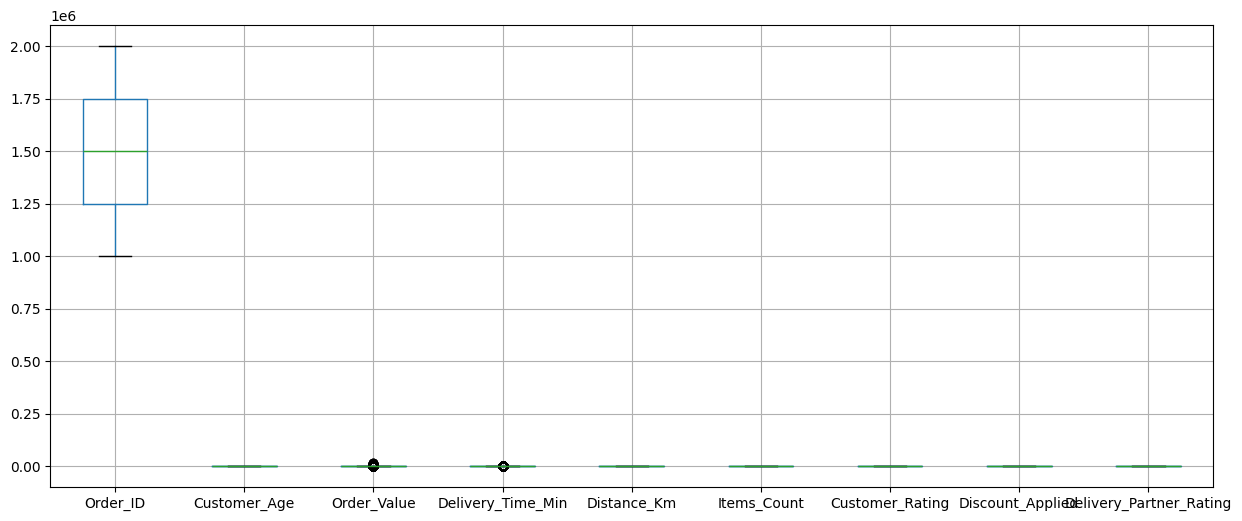

In [93]:
# Box Plot

plt.figure(figsize= (15,6))
df.boxplot()


<Axes: >

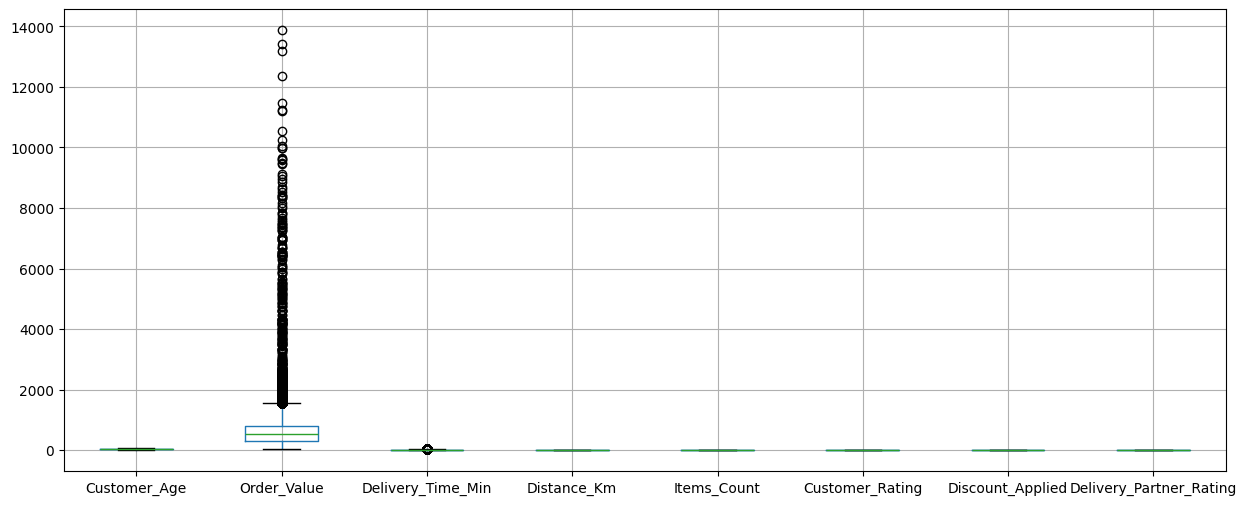

In [94]:
# Box Plot without 'Order_ID' column

plt.figure(figsize= (15,6))

df.drop(columns = ['Order_ID']).boxplot()

In [95]:
# 1) Percentile (capping) Method (used in industry)

#df= df['Order_Value'].clip(upper = 2500)

In [99]:
# 2) Filtering

df = df[df['Order_Value'] <= 2500]

In [100]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,19.0,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


<Axes: >

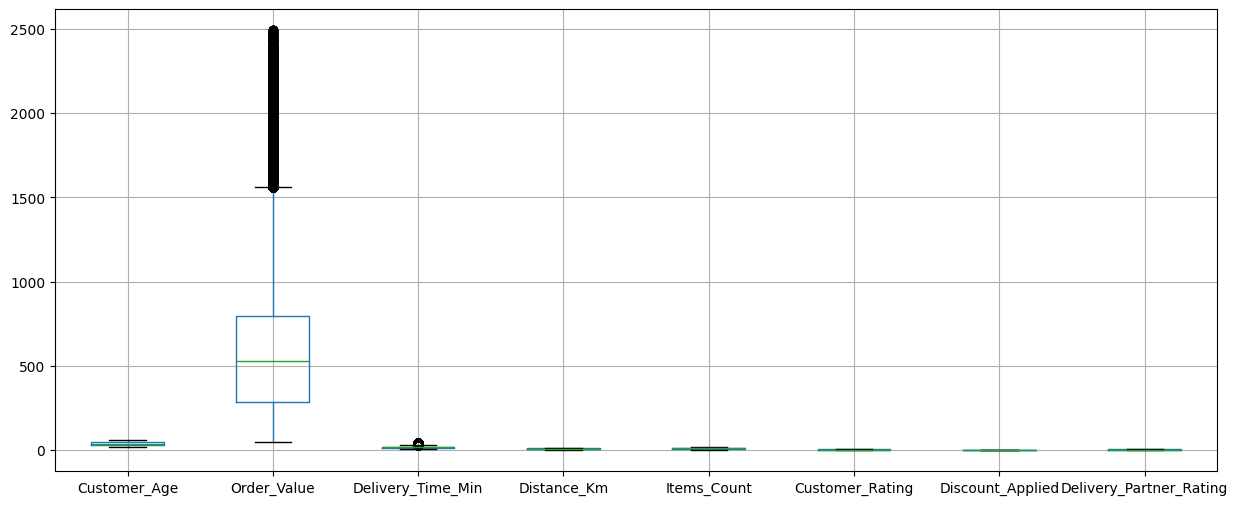

In [101]:
# Box Plot without 'Order_ID' column

plt.figure(figsize= (15,6))

df.drop(columns = ['Order_ID']).boxplot()

<Axes: >

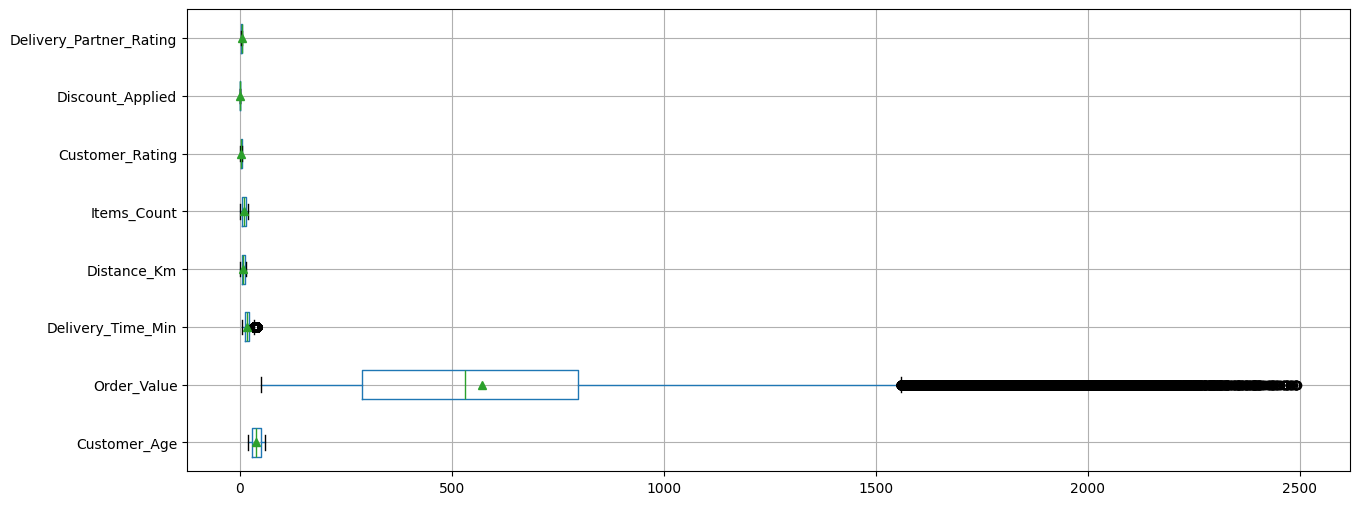

In [102]:
# Box Plot without 'Order_ID' column

plt.figure(figsize= (15,6))

df.drop(columns = ['Order_ID']).boxplot(vert = False, showmeans = True)

In [103]:
# statistics summery
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,9.477520e+05,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000
mean,1.500028e+06,38.471165,570.912385,16.502070,7.750046,10.313292,3.042843,0.400786,3.749173
std,2.887273e+05,12.118982,374.174789,6.330106,4.186990,5.630770,1.161112,0.490058,0.684365
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.249939e+06,28.000000,287.923000,12.362000,4.130000,5.000000,2.100000,0.000000,3.200000
50%,1.500026e+06,38.000000,531.674100,16.384000,7.750000,10.000000,3.015637,0.000000,3.753051
75%,1.750145e+06,49.000000,796.556650,20.302000,11.380000,15.000000,4.000000,1.000000,4.300000
max,2.000000e+06,59.000000,2492.435250,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [104]:
df.info()

<class 'pandas.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  int64  
 1   Company                  947752 non-null  str    
 2   City                     947752 non-null  str    
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  float64
 5   Delivery_Time_Min        947752 non-null  float64
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  float64
 8   Product_Category         947752 non-null  str    
 9   Payment_Method           947752 non-null  str    
 10  Customer_Rating          947752 non-null  float64
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  float64
dtypes: float64(6), int64(3), str(4)
memory usage: 101.2 MB


### Change Column Data-type

In [123]:
# change data-type of order ID

df['Order_ID']= df['Order_ID'].astype(str)

In [124]:
df.head()


,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.0,19.0,12.0,12.0,Dairy,Wallet,2.0,1,3.0
1,1000002,Flipkart Minutes,Amritsar,56,1007.0,20.0,13.0,10.0,Snacks,Cash on Delivery,2.0,0,3.0
2,1000003,Flipkart Minutes,Mumbai,18,1212.0,17.0,5.0,19.0,Personal Care,Cash on Delivery,3.0,0,4.0
3,1000004,Swiggy Instamart,Delhi,23,1179.0,6.0,6.0,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.0,12.0,2.0,13.0,Household,Wallet,4.0,0,5.0


In [127]:
# Round-off the float values

df['Order_Value'] = np.round(df['Order_Value'])
df['Delivery_Time_Min'] = np.round(df['Delivery_Time_Min'])
df['Distance_Km'] = np.round(df['Distance_Km'], 1)
df['Customer_Rating'] = np.round(df['Customer_Rating'])
df['Delivery_Partner_Rating'] = np.round(df['Delivery_Partner_Rating'])

In [122]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.0,19.0,12.0,12.0,Dairy,Wallet,2.0,1,3.0
1,1000002,Flipkart Minutes,Amritsar,56,1007.0,20.0,13.0,10.0,Snacks,Cash on Delivery,2.0,0,3.0
2,1000003,Flipkart Minutes,Mumbai,18,1212.0,17.0,5.0,19.0,Personal Care,Cash on Delivery,3.0,0,4.0
3,1000004,Swiggy Instamart,Delhi,23,1179.0,6.0,6.0,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.0,12.0,2.0,13.0,Household,Wallet,4.0,0,5.0


In [129]:
# change the data-type of float columns to integer
df['Order_Value']= df['Order_Value'].astype(int)
df['Delivery_Time_Min']= df['Delivery_Time_Min'].astype(int)
df['Items_Count']= df['Items_Count'].astype(int)
df['Customer_Rating']= df['Customer_Rating'].astype(int)
df['Delivery_Partner_Rating']= df['Delivery_Partner_Rating'].astype(int)


In [130]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,13.0,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,5.0,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.0,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.0,13,Household,Wallet,4,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72,18,3.0,19,Fruits & Vegetables,Wallet,4,0,3
999996,1999997,Swiggy Instamart,Mumbai,33,1510,18,11.0,9,Beverages,Debit Card,4,1,4
999997,1999998,Jio Mart,Noida,29,637,18,3.0,6,Groceries,Cash on Delivery,3,0,5
999998,1999999,Dunzo,Pune,42,1103,13,8.0,12,Snacks,Wallet,4,1,4


In [133]:
df.info()

<class 'pandas.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  str    
 1   Company                  947752 non-null  str    
 2   City                     947752 non-null  str    
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  int64  
 5   Delivery_Time_Min        947752 non-null  int64  
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  int64  
 8   Product_Category         947752 non-null  str    
 9   Payment_Method           947752 non-null  str    
 10  Customer_Rating          947752 non-null  int64  
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 101.2 MB





### Save Cleaned And Modified dataset

In [135]:
new_path = r"C:\Users\divya\OneDrive\Desktop\Data Analyst/quick_commerce_data_modified_cleaned.csv"

In [136]:
df.to_csv(new_path, index = False)

### Load Cleaned dataset

In [137]:
df = pd.read_csv(r"C:\Users\divya\OneDrive\Desktop\Data Analyst/quick_commerce_data_modified_cleaned.csv")

In [138]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,13.0,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,5.0,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.0,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.0,13,Household,Wallet,4,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
947747,1999996,Big Basket,Mumbai,48,72,18,3.0,19,Fruits & Vegetables,Wallet,4,0,3
947748,1999997,Swiggy Instamart,Mumbai,33,1510,18,11.0,9,Beverages,Debit Card,4,1,4
947749,1999998,Jio Mart,Noida,29,637,18,3.0,6,Groceries,Cash on Delivery,3,0,5
947750,1999999,Dunzo,Pune,42,1103,13,8.0,12,Snacks,Wallet,4,1,4


## Business Question

###  Q.1) Which quick commerce platform has the highest total revenue? 

In [139]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,13.0,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,5.0,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.0,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.0,13,Household,Wallet,4,0,5


In [143]:
# Group data - Calculate total order value for companies

company_revenue = df.groupby('Company')['Order_Value'].sum()

In [144]:
# sort Grouped Data

company_revenue.sort_values()

Company
Jio Mart            57112860
Dunzo               64007579
Amazon Now          65832504
Flipkart Minutes    66998289
Big Basket          67884762
Zepto               70339672
Blinkit             72499575
Swiggy Instamart    76407756
Name: Order_Value, dtype: int64

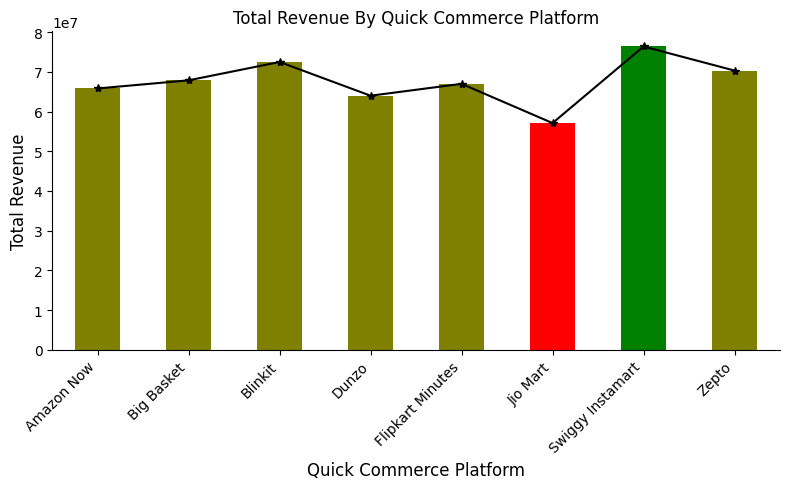

In [162]:
# Bar and line Chart

plt.figure(figsize = (8,5))

# Find max and min revenue
max_val = company_revenue.max()
min_val = company_revenue.min()

# Assign clors based on value 
colors = ['green' if val == max_val else
          'red' if val == min_val else
          'olive'
          for val in company_revenue
         ]

# Draw bar & Line Chart at once 
company_revenue.plot( kind ='bar', color = colors)
company_revenue.plot( kind = 'line', color = 'black', marker = '*')

plt.xlabel("Quick Commerce Platform", fontsize = 12)
plt.ylabel("Total Revenue", fontsize = 12)
plt.title("Total Revenue By Quick Commerce Platform")
plt.xticks(rotation =45, ha ='right')

ax = plt.gca()  # gca - get current axis

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

plt.show()



### Q.2) Which platform has the highest average order value (AOV)?

In [163]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,13.0,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,5.0,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.0,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.0,13,Household,Wallet,4,0,5


In [166]:
AOV = df.groupby('Company')['Order_Value'].mean()

Company
Amazon Now          557.510429
Big Basket          575.065542
Blinkit             609.819198
Dunzo               540.317053
Flipkart Minutes    563.176472
Jio Mart            482.914592
Swiggy Instamart    644.927250
Zepto               593.258314
Name: Order_Value, dtype: float64

In [168]:
AOV = df.groupby('Company')['Order_Value'].mean().sort_values()
AOV

Company
Jio Mart            482.914592
Dunzo               540.317053
Amazon Now          557.510429
Flipkart Minutes    563.176472
Big Basket          575.065542
Zepto               593.258314
Blinkit             609.819198
Swiggy Instamart    644.927250
Name: Order_Value, dtype: float64

In [169]:
type(AOV)

pandas.Series

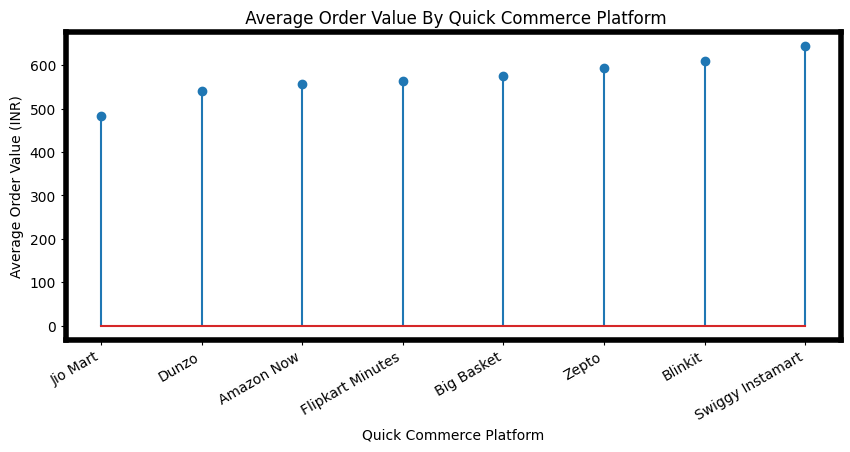

In [180]:
# Stem Chart

plt.figure(figsize = (10,4))
plt.stem(AOV.index, AOV.values)


plt.xlabel("Quick Commerce Platform")
plt.ylabel("Average Order Value (INR)")
plt.title(" Average Order Value By Quick Commerce Platform")
plt.xticks(rotation=30, ha='right')

ax = plt.gca()

# Highlight all four borders 
ax.spines['top'].set_linewidth(4)
ax.spines['right'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)
ax.spines['bottom'].set_linewidth(4)
plt.show()



### Q.3) How Does Customer Rating Vary Across  Platforms?

In [181]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,13.0,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,5.0,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.0,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.0,13,Household,Wallet,4,0,5


In [188]:
# Group Data - Calculate average rating for Companies
df.groupby('Company')['Customer_Rating'].mean().sort_values()

Company
Dunzo               2.428024
Jio Mart            2.819747
Amazon Now          2.913417
Flipkart Minutes    3.016316
Big Basket          3.097902
Zepto               3.203062
Swiggy Instamart    3.279443
Blinkit             3.580762
Name: Customer_Rating, dtype: float64

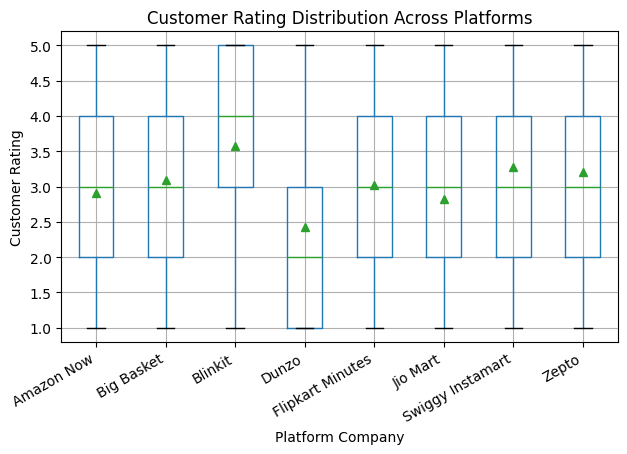

In [200]:
# Box Plot

df.boxplot(column = 'Customer_Rating', by = 'Company', showmeans = True)

plt.suptitle("")
plt.title("Customer Rating Distribution Across Platforms")
plt.xlabel("Platform Company")
plt.ylabel("Customer Rating")
plt.xticks(rotation = 30, ha = 'right') # Rotate labelfor clarity

plt.tight_layout()  # Auto Adjustingspaces 
plt.show()


In [201]:
 # Group Data 


grouped_rating = df.groupby(['Company', 'Customer_Rating'])['Customer_Rating'].count().unstack(fill_value=0)

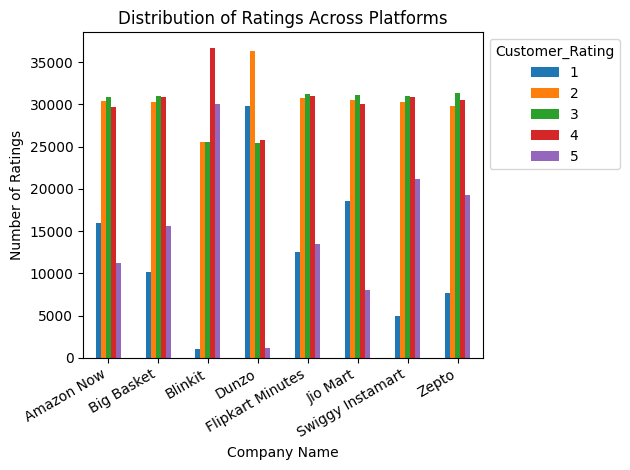

In [204]:
# Bar Chart For Grouped Ratings

grouped_rating.plot(kind = 'bar')

plt.xlabel("Company Name")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Ratings Across Platforms")
plt.xticks(rotation=30, ha='right')
plt.legend(title= 'Customer_Rating', bbox_to_anchor = (1,1), loc = 'upper left')
plt.tight_layout()
plt.show()


### Q.4) Does 'Delivery TIme' affects the 'Delivery Partner Ratings'?

In [205]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,13.0,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,5.0,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.0,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.0,13,Household,Wallet,4,0,5


In [206]:
df['Delivery_Time_Min'].mean()

np.float64(16.506619875241626)

In [207]:
df['Delivery_Partner_Rating'].mean()



np.float64(3.80029480285982)

In [214]:
# Calculate average rating for delevery timings

x = df.groupby('Delivery_Time_Min')['Delivery_Partner_Rating'].mean()

pandas.Series

In [209]:
df['Delivery_Time_Min'].corr(df['Delivery_Partner_Rating'])

np.float64(-0.0027773408026697368)

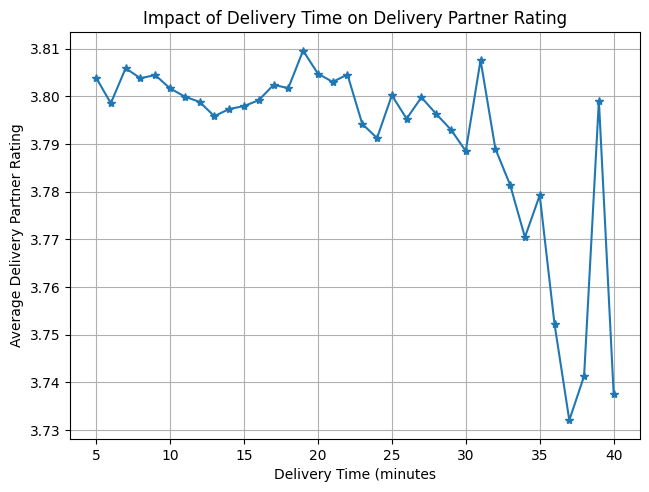

In [222]:
# line chart 
x.plot(marker='*')
plt.tight_layout()
plt.xlabel("Delivery Time (minutes")
plt.ylabel("Average Delivery Partner Rating")
plt.title("Impact of Delivery Time on Delivery Partner Rating")
plt.grid(True)
plt.show()

In [230]:
#syntex : pd.cut(col_name, bins, labels)

df['Delivery_Time_Bucket'] = pd.cut(df['Delivery_Time_Min'], 
                                    bins = (0,10,20,30,40,50), 
                                    labels = ("Very Fast Delivery", "Fast Delivery", "Normal Delivery", "Slow Delivery", "Very Slow Delivery"))

In [229]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,13.0,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,5.0,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.0,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.0,13,Household,Wallet,4,0,5,Fast Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947747,1999996,Big Basket,Mumbai,48,72,18,3.0,19,Fruits & Vegetables,Wallet,4,0,3,Fast Delivery
947748,1999997,Swiggy Instamart,Mumbai,33,1510,18,11.0,9,Beverages,Debit Card,4,1,4,Fast Delivery
947749,1999998,Jio Mart,Noida,29,637,18,3.0,6,Groceries,Cash on Delivery,3,0,5,Fast Delivery
947750,1999999,Dunzo,Pune,42,1103,13,8.0,12,Snacks,Wallet,4,1,4,Fast Delivery


In [234]:

bucket_avg = df.groupby('Delivery_Time_Bucket')['Delivery_Partner_Rating'].mean()
bucket_avg

Delivery_Time_Bucket
Very Fast Delivery    3.803231
Fast Delivery         3.800835
Normal Delivery       3.798345
Slow Delivery         3.783646
Name: Delivery_Partner_Rating, dtype: float64

In [235]:
df['Delivery_Time_Min'].max()

np.int64(40)

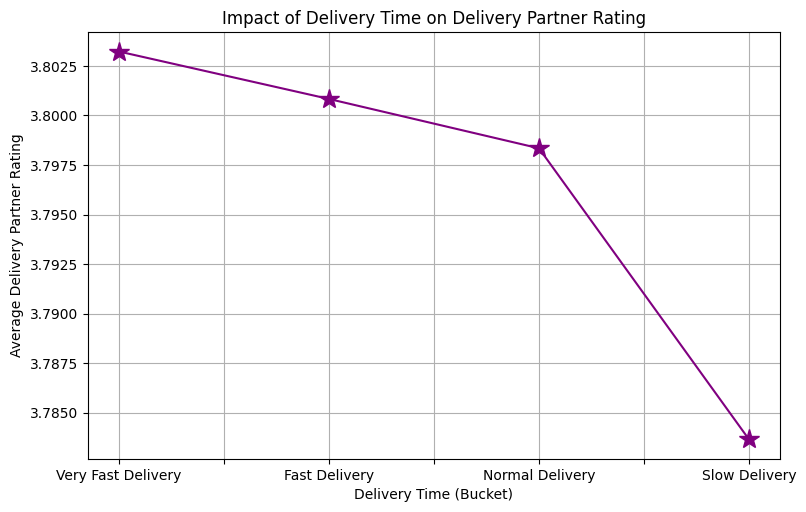

In [238]:
plt.figure(figsize=(8,5))
bucket_avg.plot(marker='*', markersize = 15 , color = 'purple')
plt.tight_layout()
plt.grid(True)
plt.xlabel("Delivery Time (Bucket)")
plt.ylabel("Average Delivery Partner Rating")
plt.title("Impact of Delivery Time on Delivery Partner Rating")
plt.show()


### Q.5) What is the most popular product category on swiggy instamart, for the people of age between 30-40,in Mumbai

In [239]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,13.0,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,5.0,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.0,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.0,13,Household,Wallet,4,0,5,Fast Delivery


In [243]:
df_pc = df[
              (df['Company'] == 'Swiggy Instamart') & 
              ((df['Customer_Age'] >= 30) &  (df['Customer_Age'] < 40))& 
              (df['City'] == 'Mumbai')
    ]
df_pc

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
512,1000537,Swiggy Instamart,Mumbai,38,1157,14,6.0,18,Beverages,Cash on Delivery,4,1,4,Fast Delivery
872,1000910,Swiggy Instamart,Mumbai,32,926,20,14.0,3,Dairy,UPI,2,0,5,Fast Delivery
1148,1001204,Swiggy Instamart,Mumbai,37,234,19,8.0,6,Dairy,Debit Card,5,0,4,Fast Delivery
2783,1002919,Swiggy Instamart,Mumbai,31,423,15,4.0,10,Dairy,Cash on Delivery,2,0,3,Fast Delivery
4038,1004252,Swiggy Instamart,Mumbai,36,50,15,2.0,12,Dairy,Credit Card,3,0,3,Fast Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945478,1997611,Swiggy Instamart,Mumbai,37,448,19,14.0,17,Fruits & Vegetables,Cash on Delivery,5,0,5,Fast Delivery
947020,1999243,Swiggy Instamart,Mumbai,32,747,13,2.0,12,Household,UPI,5,1,5,Fast Delivery
947036,1999259,Swiggy Instamart,Mumbai,35,50,18,8.0,4,Personal Care,Debit Card,5,0,5,Fast Delivery
947444,1999681,Swiggy Instamart,Mumbai,39,375,19,9.0,6,Household,Wallet,2,0,4,Fast Delivery


In [248]:
df_pc['Product_Category'].value_counts()

Product_Category
Dairy                  368
Fruits & Vegetables    343
Groceries              341
Household              340
Snacks                 329
Personal Care          305
Beverages              299
Name: count, dtype: int64

### Q.6) Which cities should these company expand into based on performances?

In [249]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,13.0,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,5.0,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.0,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.0,13,Household,Wallet,4,0,5,Fast Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947747,1999996,Big Basket,Mumbai,48,72,18,3.0,19,Fruits & Vegetables,Wallet,4,0,3,Fast Delivery
947748,1999997,Swiggy Instamart,Mumbai,33,1510,18,11.0,9,Beverages,Debit Card,4,1,4,Fast Delivery
947749,1999998,Jio Mart,Noida,29,637,18,3.0,6,Groceries,Cash on Delivery,3,0,5,Fast Delivery
947750,1999999,Dunzo,Pune,42,1103,13,8.0,12,Snacks,Wallet,4,1,4,Fast Delivery


In [258]:
# Group Data and Apply Aggregate Functions

city_perf = df.groupby(['Company','City']).agg(
                                   Total_orders = ('Order_ID', 'count'),
                                   Avg_Rating=('Customer_Rating', 'mean'),
                                   Avg_Delivery_Time=('Delivery_Time_Min', 'mean'),
                                   Total_Revenue=('Order_Value', 'sum')).reset_index()                                                     
city_perf    

,Company,City,Total_orders,Avg_Rating,Avg_Delivery_Time,Total_Revenue
0,Amazon Now,Amritsar,9929,2.896666,18.167388,5469439
1,Amazon Now,Bengluru,9905,3.387683,19.183342,5629936
2,Amazon Now,Chennai,9847,2.904032,18.138722,5363559
3,Amazon Now,Delhi,9918,2.989716,8.294616,5891026
4,Amazon Now,Gurgaon,9797,2.921711,18.166173,6680388
...,...,...,...,...,...,...
91,Zepto,Jaipur,9678,3.112213,13.145278,4621428
92,Zepto,Kolkata,9825,3.173028,8.302901,5776955
93,Zepto,Mumbai,9861,3.412230,10.152013,6046485
94,Zepto,Noida,10070,3.206653,8.297617,7070769


In [261]:
# Filtering Best Cities Based On Given Condition

best_cities = city_perf[
                         (city_perm['Avg_Rating'] >= 3.5) &
                         (city_perf['Avg_Delivery_Time'] <= 15) &
                          (city_perf['Total_orders'] > city_perf['Total_orders'].median())
                        ]
best_cities

,Company,City,Total_orders,Avg_Rating,Avg_Delivery_Time,Total_Revenue
24,Blinkit,Amritsar,9932,3.589106,14.199154,6006361
26,Blinkit,Chennai,9876,3.580903,14.135581,5921870
28,Blinkit,Gurgaon,10078,3.579381,14.199345,7374774
32,Blinkit,Kolkata,10004,3.566873,14.142743,6003384
35,Blinkit,Pune,9908,3.583266,14.164110,5930415
85,Zepto,Bengluru,9971,3.598636,9.198977,6041668


In [262]:
best_cities[['Company','City']]

,Company,City
24,Blinkit,Amritsar
26,Blinkit,Chennai
28,Blinkit,Gurgaon
32,Blinkit,Kolkata
35,Blinkit,Pune
85,Zepto,Bengluru


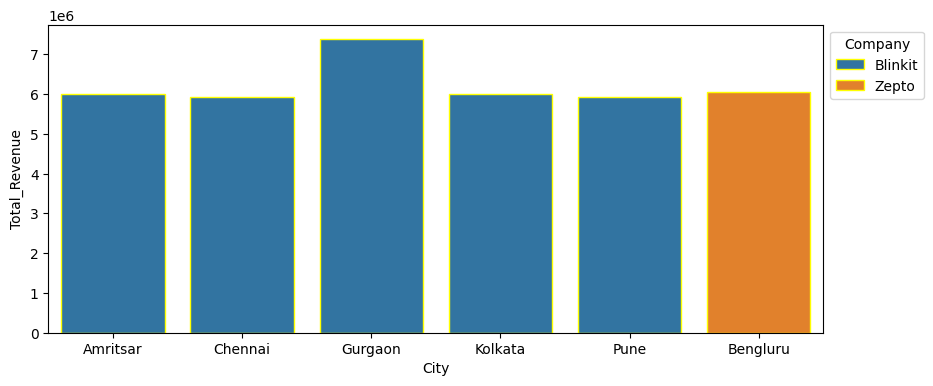

In [267]:
plt.figure(figsize=(10,4))
sns.barplot(data = best_cities, x='City', y='Total_Revenue', hue = 'Company', edgecolor = 'yellow' )
plt.legend(title = 'Company', bbox_to_anchor = (1,1))
plt.show()

### Q.7) Are discountings increasing order volume or just reducing revenue?

In [268]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,13.0,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,5.0,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.0,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.0,13,Household,Wallet,4,0,5,Fast Delivery


In [269]:
# Count the number of orders with or without discount

df['Discount_Applied'].value_counts()

Discount_Applied
0    567906
1    379846
Name: count, dtype: int64

In [283]:
# Group Data - Calculate sum of itmes 

dis_items_count = df.groupby('Discount_Applied')['Items_Count'].sum()
dis_items_count

Discount_Applied
0    5854258
1    3920185
Name: Items_Count, dtype: int64

In [284]:
# Group Data - Calculate average order value

dis_order_value = df.groupby('Discount_Applied')['Order_Value'].mean()
dis_order_value 

Discount_Applied
0    476.417152
1    712.190830
Name: Order_Value, dtype: float64

In [285]:
a=df['Discount_Applied'].unique()
print(a)

[1 0]


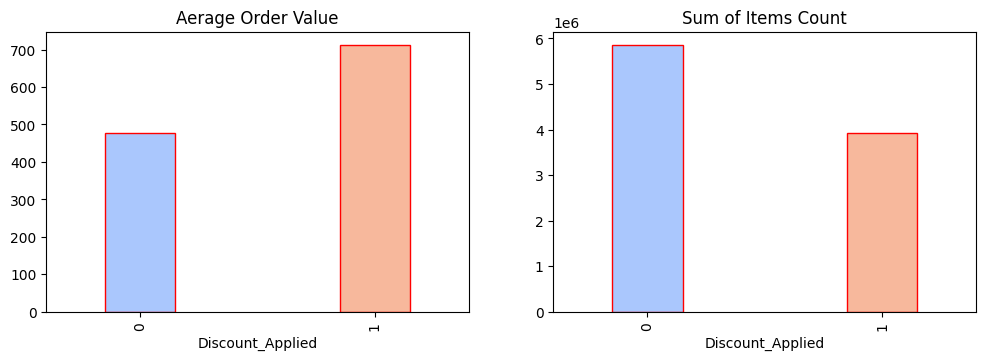

In [289]:
plt.figure(figsize=(12,8))

colors = sns.color_palette("coolwarm", len(a))

plt.subplot(2,2,1)
dis_order_value.plot(kind='bar', width = 0.3, edgecolor = 'red', color = colors)
plt.title("Aerage Order Value")

plt.subplot(2,2,2)
dis_items_count.plot(kind='bar', width = 0.3, edgecolor = 'red', color = colors)
plt.title("Sum of Items Count")

plt.show()

### Q.8) Which Company has THe Best Operational Efficiency (Delivery Time vs Order Volume)?

In [290]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,13.0,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,5.0,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.0,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.0,13,Household,Wallet,4,0,5,Fast Delivery


In [296]:
company_efficiency=df.groupby('Company').agg( Total_Orders = ('Order_ID', 'count'),
                            Avg_Delivery_Time = ('Delivery_Time_Min', 'mean')
                         ).reset_index()
    
company_efficiency                        

,Company,Total_Orders,Avg_Delivery_Time
0,Amazon Now,118083,18.984155
1,Big Basket,118047,18.027345
2,Blinkit,118887,15.121771
3,Dunzo,118463,14.177060
4,Flipkart Minutes,118965,17.045080
5,Jio Mart,118267,23.013224
6,Swiggy Instamart,118475,16.072690
7,Zepto,118565,9.644313


In [300]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [303]:
# Normalize values for fair compariso
from sklearn.preprocessing import MinMaxScaler

#Scaling both coloumns to the samr range (0 to 1) so that they can be fairly compared and combined

scaler = MinMaxScaler()  # Create a Scaling object 

company_efficiency[['Total_Orders_Scaled', 'Avg_Delivery_Time_Scaled']] = scaler.fit_transform(
                                                                                            company_efficiency[['Total_Orders', 'Avg_Delivery_Time']]
                                                                                              )

In [304]:
company_efficiency

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled
0,Amazon Now,118083,18.984155,0.039216,0.698624
1,Big Basket,118047,18.027345,0.000000,0.627054
2,Blinkit,118887,15.121771,0.915033,0.409716
3,Dunzo,118463,14.177060,0.453159,0.339051
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580
5,Jio Mart,118267,23.013224,0.239651,1.000000
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845
7,Zepto,118565,9.644313,0.564270,0.000000


In [307]:
# Efficiency Score (highest orders, lower time)

company_efficiency['Efficiency_Score'] = company_efficiency['Total_Orders_Scaled'] - company_efficiency['Avg_Delivery_Time_Scaled']
company_efficiency

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_Score
0,Amazon Now,118083,18.984155,0.039216,0.698624,-0.659408
1,Big Basket,118047,18.027345,0.000000,0.627054,-0.627054
2,Blinkit,118887,15.121771,0.915033,0.409716,0.505317
3,Dunzo,118463,14.177060,0.453159,0.339051,0.114108
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580,0.446420
5,Jio Mart,118267,23.013224,0.239651,1.000000,-0.760349
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845,-0.014614
7,Zepto,118565,9.644313,0.564270,0.000000,0.564270


In [309]:
eff = company_efficiency.sort_values(by = 'Efficiency_Score' , ascending = False)
eff

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_Score
7,Zepto,118565,9.644313,0.564270,0.000000,0.564270
2,Blinkit,118887,15.121771,0.915033,0.409716,0.505317
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580,0.446420
3,Dunzo,118463,14.177060,0.453159,0.339051,0.114108
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845,-0.014614
1,Big Basket,118047,18.027345,0.000000,0.627054,-0.627054
0,Amazon Now,118083,18.984155,0.039216,0.698624,-0.659408
5,Jio Mart,118267,23.013224,0.239651,1.000000,-0.760349


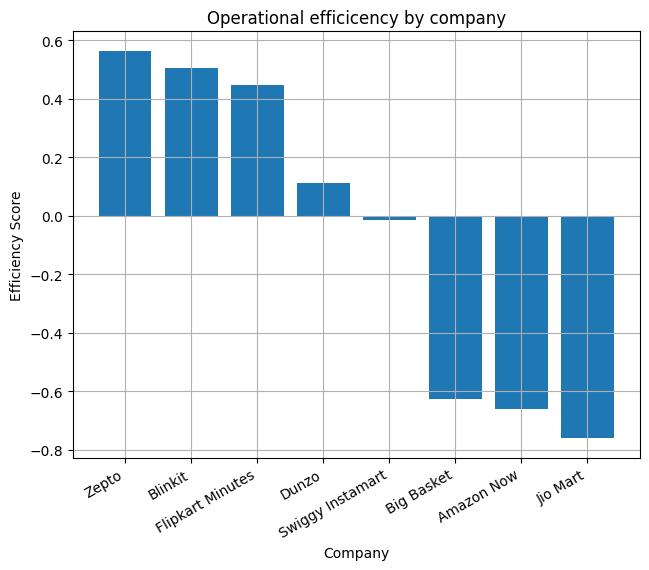

In [315]:
plt.bar(eff['Company'], eff['Efficiency_Score'])
plt.tight_layout()
plt.xlabel('Company')
plt.ylabel('Efficiency Score')
plt.title('Operational efficicency by company')
plt.grid(True)
plt.xticks(rotation = 30, ha='right')
plt.show()

In [316]:
eff

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_Score
7,Zepto,118565,9.644313,0.564270,0.000000,0.564270
2,Blinkit,118887,15.121771,0.915033,0.409716,0.505317
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580,0.446420
3,Dunzo,118463,14.177060,0.453159,0.339051,0.114108
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845,-0.014614
1,Big Basket,118047,18.027345,0.000000,0.627054,-0.627054
0,Amazon Now,118083,18.984155,0.039216,0.698624,-0.659408
5,Jio Mart,118267,23.013224,0.239651,1.000000,-0.760349


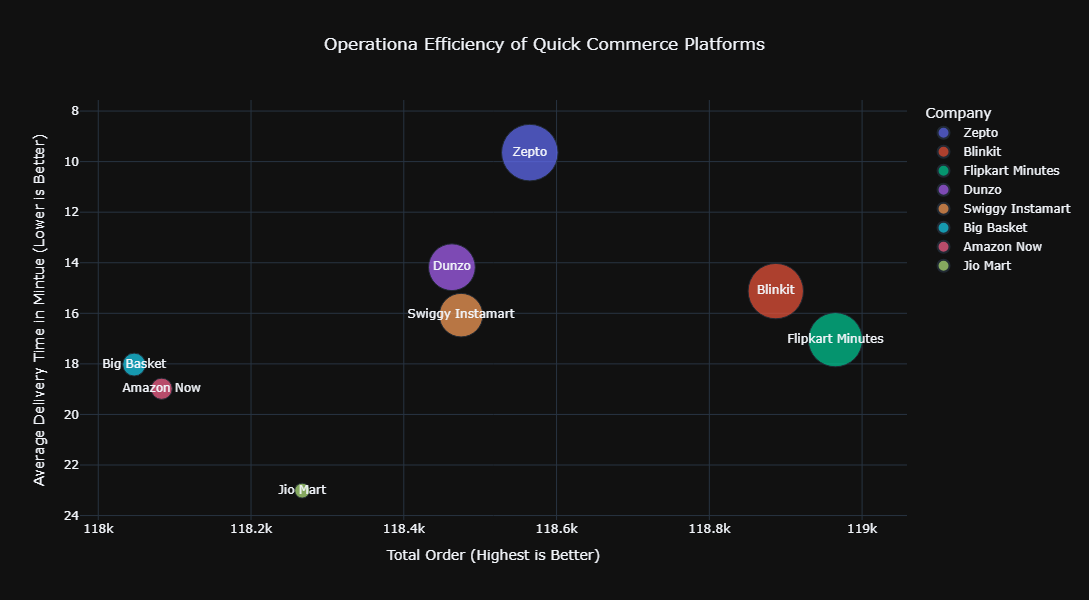

In [328]:
# use Plotly library - scatter bubble plot

import plotly.express as px 
# create positive bubble size
min_eff = eff['Efficiency_Score'].min()
eff['Bubble Size'] = eff['Efficiency_Score'] - min_eff + 0.1
fig = px.scatter( eff, x = 'Total_Orders', y = 'Avg_Delivery_Time', size = 'Bubble Size', color = 'Company',
                text = 'Company', title='Operationa Efficiency of Quick Commerce Platforms',
                hover_data = {'Total_Orders': True, 'Avg_Delivery_Time': ':.2f', 'Efficiency_Score': ':.3f'}, size_max = 40)

# Make LAbel Cleaner 
fig.update_traces(textposition = 'middle center')

#Improve Chart 

fig.update_layout(
                   xaxis_title = 'Total Order (Highest is Better)',
                   yaxis_title = 'Average Delivery Time in Mintue (Lower is Better)',
                   title_x =0.5,
                   template= 'plotly_dark',
                   height = 600)
                   
# Reverse y axis so that best performers appear higher
fig.update_yaxes(autorange = 'reversed')


fig.show()

# Mini Dashboard

C:\Users\divya\AppData\Local\Temp\ipykernel_19964\4191574262.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = Company_Matrics, x = 'Company', y = 'Orders', palette = 'Set2' )
C:\Users\divya\AppData\Local\Temp\ipykernel_19964\4191574262.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = Company_Matrics, x = 'Company', y = 'Revenue', palette = 'Set2' )
C:\Users\divya\AppData\Local\Temp\ipykernel_19964\4191574262.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = Company_Matrics, x = 'Company', y = 'Avg_Delivery_Tim

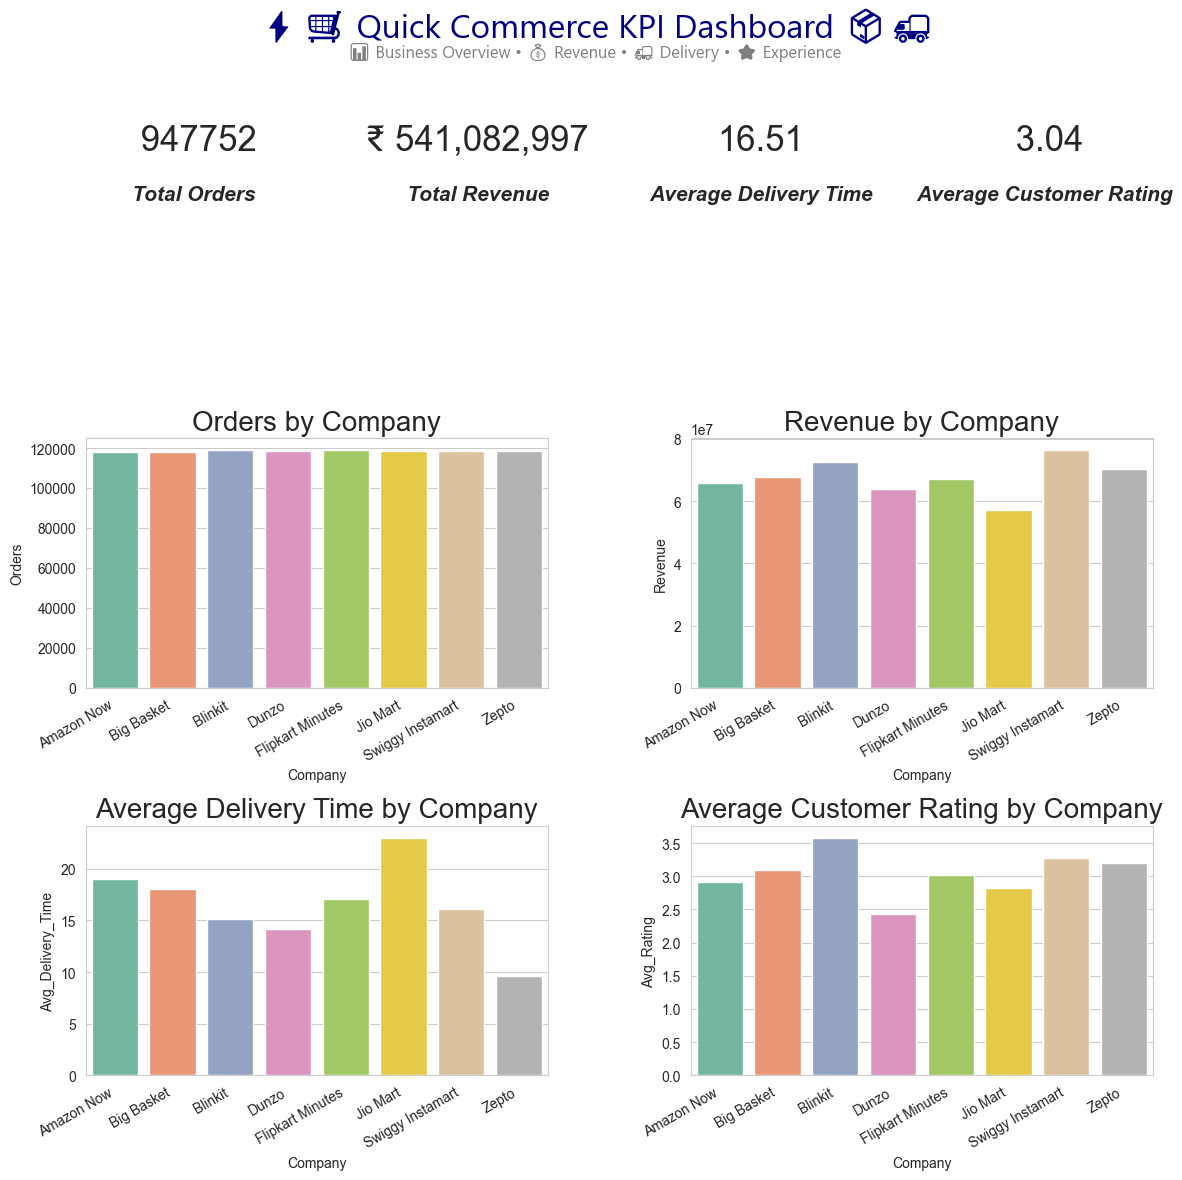

<Figure size 640x480 with 0 Axes>

In [397]:
# Create Dasboard Layout 
# ------------------------

fig = plt.figure(figsize = (12,12))

sns.set_style("whitegrid")

# -------------------------
# KPI Calculation
# -------------------------

total_orders = df['Order_ID'].count()
total_revenue = df['Order_Value'].sum()
avg_delivery_time = df['Delivery_Time_Min'].mean()
avg_rating = df['Customer_Rating'].mean()

# ---------------------------
# KPI Cards
# ---------------------------

plt.subplot2grid((3,4), (0,0))
plt.axis('off')
plt.text(0.5, 0.6, f"{total_orders: }", fontsize = 25, ha = 'center')
plt.text(0.5, 0.4, "Total Orders", fontsize = 15, ha = 'center', fontstyle = 'italic', fontweight ='bold')

plt.subplot2grid((3,4), (0,1))
plt.axis('off')
plt.text(0.5, 0.6, f"₹{total_revenue: ,}", fontsize = 25, ha = 'center')
plt.text(0.5, 0.4, "Total Revenue", fontsize = 15, ha = 'center', fontstyle = 'italic', fontweight ='bold')

plt.subplot2grid((3,4), (0,2))
plt.axis('off')
plt.text(0.5, 0.6, f"{avg_delivery_time:.2f}", fontsize = 25, ha = 'center')
plt.text(0.5, 0.4, "Average Delivery Time", fontsize = 15, ha = 'center', fontstyle = 'italic', fontweight ='bold')

plt.subplot2grid((3,4), (0,3))
plt.axis('off')
plt.text(0.5, 0.6, f"{avg_rating: .2f}", fontsize = 25, ha = 'center' )
plt.text(0.5, 0.4, "Average Customer Rating", fontsize = 15, fontstyle = 'italic', fontweight = 'bold', ha = 'center')


# -----------------------
# Company Level 
# ------------------------

Company_Matrics = df.groupby('Company').agg(Orders = ('Order_ID', 'count'),
                          Revenue = ('Order_Value', 'sum'),
                          Avg_Delivery_Time = ('Delivery_Time_Min', 'mean'),
                          Avg_Rating = ('Customer_Rating', 'mean')
                         )
# -------------------------
# Chart Selection
# -------------------------

# Order by Company
plt.subplot2grid((3,2), (1,0))
sns.barplot(data = Company_Matrics, x = 'Company', y = 'Orders', palette = 'Set2' )
plt.title("Orders by Company", fontsize = 20)
plt.xticks(rotation = 30, ha = 'right')

# Revenue by Company
plt.subplot2grid((3,2), (1,1))
sns.barplot(data = Company_Matrics, x = 'Company', y = 'Revenue', palette = 'Set2' )
plt.title("Revenue by Company", fontsize = 20)
plt.xticks(rotation = 30, ha = 'right')

# Average Delivery Time by Company
plt.subplot2grid((3,2), (2,0))
sns.barplot(data = Company_Matrics, x = 'Company', y = 'Avg_Delivery_Time', palette = 'Set2' )
plt.title("Average Delivery Time by Company", fontsize = 20)
plt.xticks(rotation = 30, ha = 'right')

plt.subplot2grid((3,2), (2,1))
sns.barplot(data = Company_Matrics, x = 'Company', y = 'Avg_Rating', palette = 'Set2' )
plt.title("Average Customer Rating by Company", fontsize = 20)
plt.xticks(rotation = 30, ha = 'right')

# ----------------------------------
# Dashboard Title
# ----------------------------------




# Set emoji supported font
plt.rcParams['font.family'] = 'Segoe UI Emoji'

# Main dashboard title
plt.suptitle(
    "⚡🛒 Quick Commerce KPI Dashboard 📦🚚",
    fontsize = 24,
    color = 'navy'
)

# Small subtitle under main title
plt.figtext(
    0.5, 0.94,
    "📊 Business Overview • 💰 Revenue • 🚚 Delivery • ⭐ Experience",
    ha = 'center',
    fontsize = 12,
    color = 'gray'
)

# Adjust spacing
plt.tight_layout()

# Show chart
plt.show()




plt.tight_layout()
plt.subplots_adjust(hspace = 1)
                  
plt.show()
